# 네이버 영화리뷰 감성분석

!curl -L -o ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt  # 학습용 데이터 파일 다운로드
!curl -L -o ratings_test.txt  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt   # 테스트용 데이터 파일 다운로드

In [22]:
!curl -L -o ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt  # 학습용 데이터 파일 다운로드
!curl -L -o ratings_test.txt  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt   # 테스트용 데이터 파일 다운로드

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 13.95M 100 13.95M   0      0 31.45M      0                              0
100 13.95M 100 13.95M   0      0 31.45M      0                              0
100 13.95M 100 13.95M   0      0 31.45M      0                              0
curl: (3) URL rejected: No host part in the URL
curl: (6) Could not resolve host: xn--ru4bi6eisq
curl: (6) Could not resolve host: xn--2n1bp39av7g
curl: (6) Could not resolve host: xn--pu5bl5s
curl: (6) Could not resolve host: xn--2j1bj1b12ewtu
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  4.66M 100  4.66M   0      0 21.16M      0     

In [23]:
import pandas as pd
ratings_train_df = pd.read_csv('ratings_train.txt',sep='\t')
ratings_test_df = pd.read_csv('ratings_test.txt',sep='\t')

ratings_train_df.shape,ratings_test_df.shape

((150000, 3), (50000, 3))

In [24]:
ratings_train_df = ratings_train_df.dropna(how='any')  # 하나라도 결측치가 있으면 해당 행 삭제 (기본값)
ratings_test_df = ratings_test_df.dropna(how='any')

ratings_train_df.isnull().sum(), ratings_test_df.isnull().sum()

(id          0
 document    0
 label       0
 dtype: int64,
 id          0
 document    0
 label       0
 dtype: int64)

In [25]:
ratings_train_df.shape,ratings_test_df.shape

((149995, 3), (49997, 3))

In [26]:
# 데이터 샘플링 (학습시간 단축, 메모리사용량 감안) 
ratings_train_df = ratings_train_df.sample(n=50000,random_state=42)
ratings_test_df = ratings_test_df.sample(n=5000,random_state=42)

ratings_train_df.shape,ratings_test_df.shape

((50000, 3), (5000, 3))

In [27]:
# 데이터 전처리 함수 생성
import re
from konlpy.tag import Okt

# 파일 경로 받아 불용어 로드하는 함수
def load_stopwords(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        stopwords = [line.strip() for line in f]    # 줄바꿈/공백 제거하여 리스트 가져옴

    return stopwords

# 전처리 함수
def preprocessing(sentence,okt = Okt()):    
    sentence = re.sub(r'\n', ' ', sentence)     # 개형문자 (줄바꿈) 제거
    sentence = re.sub(r'[^가-힣ㄱ-하ㅏ-ㅣ\s]', '',sentence) # 한글 외 문자 제거

    tokens = okt.morphs(sentence, stem =True)   # 형태소 분석(어간 추출)

    ko_stopwords = load_stopwords('ko_stopwords.txt')

    tokens = [token for token in tokens if token not in ko_stopwords]   # 불용어 제거

    return tokens

In [28]:
sample = """
    이런 영화 진짜 fantastic!!!
    너무 못 만들었다.
    그런데 감동이다!!!😀😀😀😀
"""

preprocessing(sample)

['이렇다', '영화', '진짜', '너무', '못', '만들다', '감동', '이다']

In [29]:
# 텍스트 전처리하고, 학습/테스트 리스트 생성
from tqdm.auto import tqdm

X_train, y_train, X_test, y_test = [],[],[],[]

for index, row in tqdm(ratings_train_df.iterrows()):    # df의 행단위 순회
    doc,label = row['document'], row['label']   
    X_train.append(preprocessing(doc))
    y_train.append(label)

for index, row in tqdm(ratings_test_df.iterrows()):
    doc,label = row['document'], row['label']
    X_test.append(preprocessing(doc))
    y_test.append(label)

print(len(X_train),len(y_train),len(X_test),len(y_test))

50000it [03:10, 262.23it/s]
5000it [00:20, 246.27it/s]

50000 50000 5000 5000


In [30]:
print(X_train[:3])
print(y_train[:3])
print(X_test[:3])
print(y_test[:3])

[['원본', '최고'], ['스릴', '감', '훈훈하다', '영화'], ['굉장하다', '평가', '되다', '영화', '중', '라고', '생각', '함']]
[1, 1, 1]
[['찌다', '여운', '하다', '인생', '최고', '미드'], ['기대', '이다'], ['신나다', '없다', '애니']]
[1, 1, 0]


In [31]:
# 토큰화 기반 정수 인코딩 준비 및 시퀀스 변환
from tensorflow.keras.preprocessing.text import Tokenizer   # 텍스트 -> 정수 시퀀스 변환 도구
from tensorflow.keras.preprocessing.sequence import pad_sequences   # 패딩(길이 통일 도구)

vocab_size = 20_000     # 단어 사전 크기 (빈도 기준 상위 2만개) 

tokenizer = Tokenizer(num_words = vocab_size, oov_token = '<OOV>')  # 사전에 없는 단어는 OOV 처리

tokenizer.fit_on_texts(X_train) # 학습 데이터로 단어사전 (word_index)

X_train_encoded = tokenizer.texts_to_sequences(X_train) # 학습 텍스트를 정수 시퀀스로 변환
X_test_encoded = tokenizer.texts_to_sequences(X_test)   

print(X_train_encoded[:3])
print(X_test_encoded[:3])

[[8739, 28], [471, 295, 794, 2], [648, 409, 16, 2, 55, 126, 32, 209]]
[[1066, 240, 4, 138, 28, 1473], [227, 9], [1540, 8, 262]]


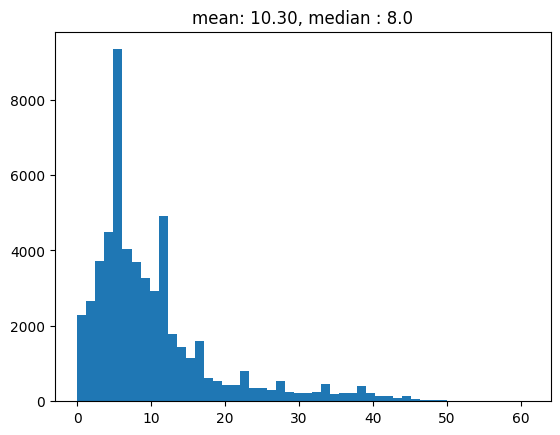

In [32]:
# 패딩 적정 길이 조사
import matplotlib.pyplot as plt
import numpy as np

X_train_len = [len(seq)for seq in X_train_encoded]  # 각 샘플 시퀀스 길이 리스트
X_test_len = [len(seq)for seq in X_test_encoded]    # 각 샘플 시퀀스 길이 리스트

mean = np.mean(X_train_len + X_test_len)            # 전체 시퀀스 길이 평균
median= np.median(X_train_len + X_test_len)         # 전체 시퀀스 길이 중앙값


plt.hist(X_train_len + X_test_len, bins=50)
plt.title(f"mean: {mean:.2f}, median : {median}")
plt.show()

In [33]:
max_len = 15    # 모델 입력 최대 시퀀스 길이

X_train_padded = pad_sequences(X_train_encoded, maxlen=max_len) # max_len 기준 패딩 / 자르기
X_test_padded = pad_sequences(X_test_encoded, maxlen=max_len)   # max_len 기준 패딩 / 자르기

In [34]:
# 정수 시퀀스를 단어로 복원해 사람이 읽을 수 있는 형태로 변환
def decode_sentence(encoded_sentence):
    # 정수 시퀀스를 찾아 해당 인덱스의 단어를 반환(없으면 '_')
    decoded = [tokenizer.index_word.get(n,'_')for n in encoded_sentence]
    return ' '.join(decoded)    # 하나의 문자열로 반환

print(X_train_padded[0])    # 패딩처리 완료된 정수 시퀀스
print(decode_sentence(X_train_padded[0]))   # 원래의 단어 형태로 복원

print(ratings_test_df.iloc[0,1])    # test 데이터 0번쨰 데이터 리뷰(document) 원문
print(X_test_padded[0])
print(decode_sentence(X_test_padded[0]))

[   0    0    0    0    0    0    0    0    0    0    0    0    0 8739
   28]
_ _ _ _ _ _ _ _ _ _ _ _ _ 원본 최고
찐한 여운과 함께...내 인생 최고의 미드
[   0    0    0    0    0    0    0    0    0 1066  240    4  138   28
 1473]
_ _ _ _ _ _ _ _ _ 찌다 여운 하다 인생 최고 미드


In [35]:
import torch
import torch.nn as nn

# 양방향 GRU 분류 모델 : 임베딩 -> 양방향 LSTM -> FC 로 감성(이진)분석 logit을 출력하는 모델
class BiLSTMSentimentNet(nn.Module):
    def __init__(self, vocab_size,embedding_dim,hidden_dim):
        super().__init__()  # nn.Module 초기화
        self.embedding = nn.Embedding(  # 임베딩 (0은 학습영향 최소화)
            vocab_size, 
            embedding_dim, 
            padding_idx = 0
        )
        self.lstm = nn.LSTM(      # LSTM 입력 : 임베딩 -> 출력 : 은닉상태/ 양방향 GRU사용
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional= True
        )
        self.fc = nn.Linear(hidden_dim*2,1)   # 정/역방향 마지막 은닉상태 결합(2H) -> 이진 로짓 1개

    # 마지막 은닉상태 (정/역)을 결합해 문장 표현을 만들고 logit 계산
    def forward(self,x):
        x = self.embedding(x)           # (B,T) -> (B,T,E)
        _,(hidden,_) = self.lstm(x)     # output : (B,T,E), hidden : (L*2,B,H)

        # 양방향 은닉상태 처리
        forward_pass = hidden[-2]       # 정방향 마지막 레이어 은닉상태 (B,H)
        backward_pass = hidden[-1]      # 역방향 마지막 레이어 은닉상태 (B,H)
        hidden_merged = torch.cat((forward_pass,backward_pass), dim=1)  # (B,H) + (B,H) -> (B,2H)

        output = self.fc(hidden_merged)    # 입력 : 마지막 레이어의 마지막 은닉상태 (B,H) ->  출력 : (B,1)
        return output   # sigmoid 적용 전 원시 logit

model = BiLSTMSentimentNet(vocab_size, embedding_dim = 100, hidden_dim = 128)
model

BiLSTMSentimentNet(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

In [36]:
for name, param in model.named_parameters():
    print(name, param.shape)    # 파라미터 이름과 텐서 shape 출력

embedding.weight torch.Size([20000, 100])
lstm.weight_ih_l0 torch.Size([512, 100])
lstm.weight_hh_l0 torch.Size([512, 128])
lstm.bias_ih_l0 torch.Size([512])
lstm.bias_hh_l0 torch.Size([512])
lstm.weight_ih_l0_reverse torch.Size([512, 100])
lstm.weight_hh_l0_reverse torch.Size([512, 128])
lstm.bias_ih_l0_reverse torch.Size([512])
lstm.bias_hh_l0_reverse torch.Size([512])
fc.weight torch.Size([1, 256])
fc.bias torch.Size([1])


In [37]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                   Param #
BiLSTMSentimentNet                       --
├─Embedding: 1-1                         2,000,000
├─LSTM: 1-2                              235,520
├─Linear: 1-3                            257
Total params: 2,235,777
Trainable params: 2,235,777
Non-trainable params: 0

# 모델 학습

In [38]:
import torch.optim as optim

# Pytorch Tensor 형태로 뱐환 (X데이터는 LongTensor, y데이터는 FloatTensor)
X_train_padded = torch.tensor(X_train_padded ,dtype=torch.long)
X_test_padded = torch.tensor(X_test_padded , dtype=torch.long)


# 라벨데이터는 2차원 형태 (N,) -> (N,1)
y_train = torch.tensor(y_train, dtype=torch.float).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float).unsqueeze(1)

print(X_train_padded.shape,X_test_padded.shape)
print(y_train.shape,y_test.shape)

torch.Size([50000, 15]) torch.Size([5000, 15])
torch.Size([50000, 1]) torch.Size([5000, 1])


In [40]:
# 학습 데이터 준비
# DataLoader 구성
from torch.utils.data import random_split, DataLoader, TensorDataset

batch_size = 64
train_size = int(len(X_train_padded) * 0.8)  # 80% 학습데이터
val_size = len(X_train_padded) - train_size  # 나머지 20% 검증데이터

# 학습 / 검증 데이터셋 분리 (X, y 데이터 묶은 후에 랜덤 분리) / 테스트 데이터셋 생성
train_dataset, val_dataset = random_split(
    TensorDataset(X_train_padded, y_train), [train_size, val_size]
)
test_dataset = TensorDataset(X_test_padded,y_test)

# 학습용 : 섞어서 배치 생성 / 검증용 : 순서 유지 / 테스트용 : 순서 유지
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(len(train_dataset),len(val_dataset),len(test_dataset))
print(len(train_dataloader),len(val_dataloader),len(test_dataloader))

40000 10000 5000
625 157 79


In [41]:
# 학습 준비
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # GPU 가용시 GPU 사용
print(f'device : {device}')

torch.cuda.empty_cache()  # GPU 미사용 캐시 메모리 정리 (OOM 대비)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()  # 이진분류 손실함수 (내부 sigmoid 포함)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# 검증 손실 개선 정체시 학습률 점차적으로 감소
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,          # 정용할 옵티마이저
    mode = 'min',       # val_loss가 최소화되는 방향 
    factor= 0.5,        # 학습률 감소 비율
    patience= 3         # 개선이 없을 경우 기다릴 에폭
)

epochs = 100

# 시각화용 지표
train_losses, val_losses, train_accs, val_accs = [], [], [], []

# 조기종료 관련
early_stopping_patience = 5
best_val_loss = float('inf')
early_stopping_counter = 0

device : cpu


In [42]:
from tqdm.auto import tqdm

# 학습
for epoch in tqdm(range(epochs)):
    total_loss, correct, total = 0, 0, 0

    # 학습
    model.train()
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()           # 이전 기울기 초기화
        output = model(inputs)          # 순전파 
        loss = criterion(output, labels)    # 손실 계산
        loss.backward()     # 역전파 : 기울기 계산
        optimizer.step()    # 파라미터 업데이트

        total_loss += loss.detach().cpu().item()   # 손실 누적(그래프 분리하고 숫자만 누적)
        p = torch.sigmoid(output)
        pred = (p >= 0.5).float()   # 임계값 기반 예측 (1.0 / 0.0)
        correct += (pred == labels).sum().float().detach().cpu().item() # 정답 누적 (그래프 분리하고 숫자만)
        total += len(labels)
    
    train_loss = total_loss / len(train_dataloader)
    train_losses.append(train_loss)
    train_acc = correct / total
    train_accs.append(train_acc)

    # 검증
    model.eval()    # 퍙가 모드
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():   # 검증시에는 기울기 계산 비활성화
        for val_inputs, val_labels in val_dataloader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

            output = model(val_inputs)
            loss = criterion(output, val_labels)

            val_loss += loss.detach().cpu().item() 
            p = torch.sigmoid(output)
            pred = (p >= 0.5).float()
            val_correct += (pred == val_labels).sum().float().detach().cpu().item()
            val_total += len(val_labels)

    val_loss = val_loss / len(val_dataloader)
    val_losses.append(val_loss)
    val_acc = val_correct / val_total
    val_accs.append(val_acc)

    scheduler.step(val_loss)
    lr = scheduler.get_last_lr()[0]


    print(f"Epoch {epoch+1}/{epochs}: Train Loss : {train_loss:.4f}, Train Acc : {train_acc:.4f}, \
    Val Loss : {val_loss:.4f}, Val Acc : {val_acc:.4f}, lr : {lr}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            print(f"{epoch + 1}에서 조기종료!")
            break

  1%|          | 1/100 [00:10<17:13, 10.44s/it]

Epoch 1/100: Train Loss : 0.6354, Train Acc : 0.6430,     Val Loss : 0.5699, Val Acc : 0.6978, lr : 0.0001


  2%|▏         | 2/100 [00:20<17:00, 10.41s/it]

Epoch 2/100: Train Loss : 0.5311, Train Acc : 0.7307,     Val Loss : 0.5189, Val Acc : 0.7356, lr : 0.0001


  3%|▎         | 3/100 [00:31<17:03, 10.56s/it]

...

Epoch 10/100: Train Loss : 0.2870, Train Acc : 0.8825,     Val Loss : 0.4332, Val Acc : 0.8067, lr : 0.0001


 11%|█         | 11/100 [02:07<17:39, 11.90s/it]

Epoch 11/100: Train Loss : 0.2688, Train Acc : 0.8918,     Val Loss : 0.4468, Val Acc : 0.8064, lr : 5e-05


 11%|█         | 11/100 [02:17<18:32, 12.50s/it]

Epoch 12/100: Train Loss : 0.2424, Train Acc : 0.9054,     Val Loss : 0.4577, Val Acc : 0.8084, lr : 5e-05
12에서 조기종료!


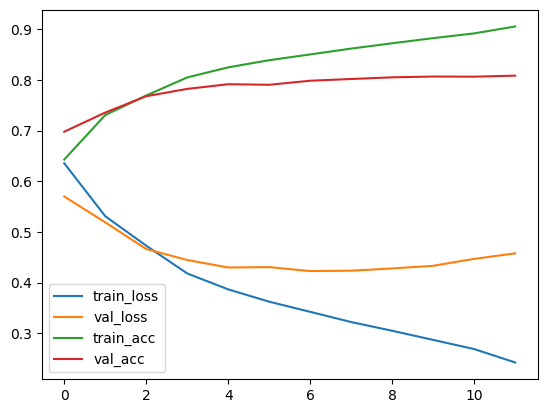

In [43]:
# 시각화

import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'train_loss' : train_losses,
    'val_loss' : val_losses,
    'train_acc' : train_accs,
    'val_acc' : val_accs
})

df.plot()       # 데이터프레임을  라인 플롯으로 그림
plt.show()

In [44]:
# 테스트 데이터로 검증
def evaluate_model(model, test_dataloader,criterion, device):    
    model.to(device).eval()
    test_loss, test_correct, test_total = 0, 0, 0
    with torch.no_grad():
        for test_inputs, test_labels in test_dataloader:
            test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

            output = model(test_inputs)
            loss = criterion(output, test_labels)

            test_loss += loss.item()
            p = torch.sigmoid(output)
            pred = (p >= 0.5).float()
            test_correct += (pred == test_labels).sum().float().detach().cpu().item()
            test_total += len(test_labels)
        test_loss = test_loss / len(test_dataloader)
        test_acc = test_correct / test_total


        return test_loss, test_acc

test_loss, test_acc = evaluate_model(model, test_dataloader,criterion, device)

print(f"Test Loss : {test_loss:.4f} , Test Acc : {test_acc:.4f}")

Test Loss : 0.4937 , Test Acc : 0.7986


In [50]:
# 여러 문장을 받아 전처리 -> 인코딩 -> 패딩 -> 모델 추론으로 긍/부정 반환하는 함수
def movie_review_sentimental_analysis(sentences):

    tokens = [preprocessing(sent)for sent in sentences] # 문장별 전처리
    encoded_sequences = tokenizer.texts_to_sequences(tokens)   # 단어를 정수 시퀀스로 변환
    padded_sequences = pad_sequences(encoded_sequences,maxlen=max_len)  # 고정 길이로 패딩/자르기 

    X = torch.tensor(padded_sequences,dtype=torch.long).to(device)  # 입력 데이터 LongTensor 변환

    model.eval()    # 평가 모드
    with torch.no_grad():   # 추론시 기울기 계산안함
        output = model(X)   # 순전파 (원시 logit 출력)
        p = torch.sigmoid(output)   # 0~1확률로 변환
        pred = (p>= 0.5).float()    # True면 1.0 Fasle면 0.0

        return ['긍정' if pr ==1 else '부정' for pr in pred]    # 예측값 한글로 반환

samples = [
    '이 영화는 못봐주겠네',
    '오랜만에 감동을 느꼇다~',
    '감독이 생각이 있나?',
    '내가 만들어도 이거보다 나을거같은데?',
    '하츄핑보다 재미없는데?',
    '봉준호 감독이야..역시'
]

movie_review_sentimental_analysis(samples)

['부정', '긍정', '부정', '부정', '부정', '긍정']